# Домашнее задание "Тематическое моделирование"

## Импорт необходимых библиотек:

In [52]:
import json
import bz2
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer


# import regex

# from scipy import sparse


# import numpy as np
# import nltk

# import seaborn as sns

# %pylab inline

## Выгрузка данных из архива

In [10]:
responses = []
with bz2.BZ2File('banki_responses.json.bz2', 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [02:16, 1467.57it/s]


Пример отзыва:

In [19]:
responses[-1]

{'city': None,
 'rating_not_checked': False,
 'title': 'Быстро и удобно',
 'num_comments': 0,
 'bank_license': 'лицензия № 1326',
 'author': 'Денис',
 'bank_name': 'Альфа-Банк',
 'datetime': '2005-04-13 17:43:00',
 'text': 'Если коротко, то мне нравится. Кридит получать - милое дело, анкета по интернету - и жди звонка. Скроки изготовления карт выдерживают, общаются вежливо.  И все эти технические навороты вроде принимающих наличные банкоматов и интернет-банков - просто отлично. Ни разу не возникала необходимость обращаться в отделение по вопросам с платежами, все решается дистанционно. И еще один плюс - не надо думать о "своем" отделении. Заходишь в любой доп. офис и без проблем получаешь все, что нужно.',
 'rating_grade': 5}

In [18]:
df = pd.DataFrame(responses)
df.head()

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,г. Ставрополь,False,Меняют проценты комиссии не предупредив и не ...,2,лицензия № 1481,643609,Сбербанк России,2015-06-05 13:51:01,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,г. Челябинск,False,Верните денежные средства за страховку,1,лицензия № 2766,anfisa-2003,ОТП Банк,2015-06-05 10:58:12,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


## Часть 1. Анализ текстов

### Посчитать количество отзывов в разных городах и на разные банки

In [33]:
# Количество отзывов в разных городах
num_reviews_by_city = df['city'].value_counts()
num_reviews_by_city

city
г. Москва                55354
г. Санкт-Петербург       14342
г. Екатеринбург           2337
г. Новосибирск            2300
г. Нижний Новгород        1976
                         ...  
г. порхов                    1
г. город Алматы              1
г. Казань, Татарстан         1
г. Эльхотово                 1
г. Тула, Тульская обл        1
Name: count, Length: 5823, dtype: int64

In [35]:
# Количество отзывов на разные банки
num_reviews_by_bank = df['bank_name'].value_counts()
num_reviews_by_bank

bank_name
Сбербанк России                  26327
Альфа-Банк                       10224
ВТБ 24                            8185
Русский Стандарт                  7943
Хоум Кредит Банк                  7549
                                 ...  
Фемили                               1
Современные Стандарты Бизнеса        1
Нэклис-Банк                          1
Жилстройбанк                         1
Юго-Восток                           1
Name: count, Length: 670, dtype: int64

### Построить гистограммы длин отзывов в символах и в словах

In [40]:
df['text_lenhth_chars'] = df['text'].str.len()
df['text_lenhth_words'] = df['text'].str.split().str.len()

Text(0.5, 1.0, 'Распределение длины отзывов в словах')

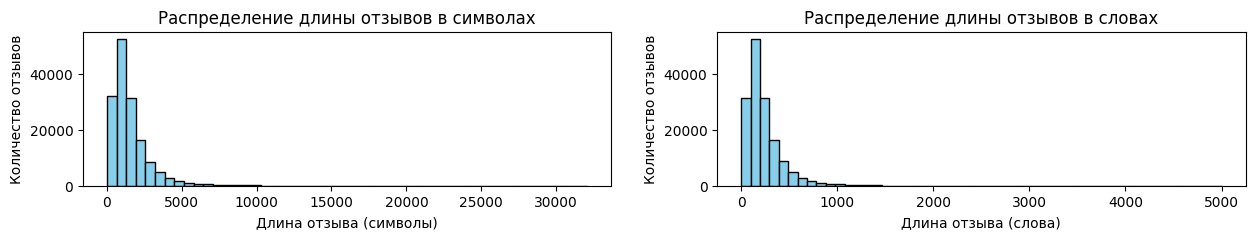

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 2))
axes[0].hist(df['text_lenhth_chars'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Длина отзыва (символы)')
axes[0].set_ylabel('Количество отзывов')
axes[0].set_title('Распределение длины отзывов в символах')

axes[1].hist(df['text_lenhth_words'], bins=51, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Длина отзыва (слова)')
axes[1].set_ylabel('Количество отзывов')
axes[1].set_title('Распределение длины отзывов в словах')


### Найти 10 самых частых:
- слов
- слов без стоп-слов
- лемм
- существительных

### Построить кривые Ципфа и Хипса

### Ответить на следующие вопросы:
- какое слово встречается чаще, "сотрудник" или "клиент"
- сколько раз встречаются слова "мощенничество" и "доверие"

## Часть 2. Тематическое моделирование

### Постройте несколько тематических моделей коллекции документов с разным числом тем. Приведите примеры понятных (интерпретируемых) тем.

### Найдите темы, в которых упомянуты конкретные банки (Сбербанк, ВТБ, другой банк). Можете ли вы их прокомментировать / объяснить?
Эта часть задания может быть сделана с использованием gensim.

## Часть 3. Классификация текстов

Сформулируем для простоты задачу бинарной классификации: будем классифицировать на два класса, то есть, различать резко отрицательные отзывы (с оценкой 1) и положительные отзывы (с оценкой 5).

### Составьте обучающее и тестовое множество: выберите из всего набора данных N1 отзывов с оценкой 1 и N2 отзывов с оценкой 5 (значение N1 и N2 – на ваше усмотрение). Используйте sklearn.model_selection.train_test_split для разделения

### Используйте любой известный вам алгоритм классификации текстов для решения задачи и получите baseline.
Сравните разные варианты векторизации текста: использование только униграм, пар или троек слов или с использованием символьных $n$-грам.

### Сравните, как изменяется качество решения задачи при использовании скрытых тем в качестве признаков:
- 1-ый вариант: $tf-idf$ преобразование (sklearn.feature_extraction.text.TfidfTransformer) и сингулярное разложение (оно же – латентый семантический анализ) (sklearn.decomposition.TruncatedSVD),
- 2-ой вариант: тематические модели LDA (sklearn.decomposition.LatentDirichletAllocation).
Используйте accuracy и F-measure для оценки качества классификации.

В ноутбуке, размещенном в папке репозитория. написан примерный Pipeline для классификации текстов.

Эта часть задания может быть сделана с использованием sklearn.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# !!! На каждом этапе Pipeline нужно указать свои параметры
# 1-ый вариант: tf-idf + LSI
# 2-ой вариант: LDA

# clf = Pipeline([
#     ('vect', CountVectorizer(analyzer = 'char', ngram_range={4,6})),
#     ('clf', RandomForestClassifier()),
# ])



clf = Pipeline([ 
    ('vect', CountVectorizer()), 
    ('tfidf', TfidfTransformer()), 
    ('tm', TruncatedSVD()), 
    ('clf', RandomForestClassifier())
])


NameError: name 'CountVectorizer' is not defined